In [1]:
# Import required packages for Assignment 4.
from pathlib import Path
import math

import pandas as pd
import numpy as np
from sklearn.metrics import pairwise
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor #, NearestNeighbors

from scipy.spatial.distance import cosine
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset
from surprise import Reader
from surprise import KNNBasic

from pandas.plotting import parallel_coordinates
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import matplotlib.pylab as plt

%matplotlib inline

In [ ]:
## Problem 7.1 Calculating Distance with Categorical Predictors

# This exercise with a tiny dataset illustrates the calculation of Euclidean distance, and the creation of binary dummies. The online education company 
# Statistics.com segments its customers and prospects into three main categories: IT professionals (IT), statisticians (Stat), and other (Other). It also 
# tracks, for each customer, the number of years since first contact (years). Consider the following customers; information about whether they have taken 
# a course or not (the outcome to be predicted) is included:

# Customer 1: Stat, 1 year, did not take course

# Customer 2: Other, 1.1 year, took course


# 7.1.a Consider now the following new prospect:

# Prospect 1: IT, 1 year

# Using the above information on the two customers and one prospect, create one dataset for all three with the categorical predictor variable transformed 
# into 2 binaries, and a similar dataset with the categorical predictor variable transformed into 3 binaries.
binaries.

# Answer:

In [2]:
# Create the required data frame for Problem 7.1 
# The variable 'Name' contains customer names (i.e. Customer1, Customer2, and Customer3).
# The variables 'Stat', 'Other', and 'IT' are three dummies for the three main categories of customers. 
# The variable 'Years' contains the number of years since first contact.
# The variable 'CourseTaken' contains whether the customer took the course or not with the binary values: course taken (1) and course not taken (0).
data = [['Customer1', 1, 0, 0, 1, 0], ['Customer2', 0, 1, 0, 1.1, 1], ['Customer3', 0, 0, 1, 1]]
df = pd.DataFrame(data,columns=['Name','Stat','Other', 'IT', 'Years', 'CourseTaken'])
print (df)

        Name  Stat  Other  IT  Years  CourseTaken
0  Customer1     1      0   0    1.0          0.0
1  Customer2     0      1   0    1.1          1.0
2  Customer3     0      0   1    1.0          NaN


In [ ]:
# 7.1.b. For each derived dataset, calculate the Euclidean distance between the prospect and each of the other two customers. (Note: while it is typical 
# to normalize data for k-NN, this is not an iron-clad rule and you may proceed here without normalization.)

In [4]:
# Calculate euclidean distances between customers 1 & 3 and customers 2 & 3 using two dummies, while dropping the dummy 'Other'.
col = ['Stat', 'IT', 'Years']
df2dummies = df[col]
d = pairwise.pairwise_distances(df2dummies, metric='euclidean')

# Display distance matrix by converting to a dataframe.
pd.DataFrame(d, columns=df.Name, index=df.Name)

Name,Customer1,Customer2,Customer3
Name,,,
Customer1,0.000000,1.004988,1.414214
Customer2,1.004988,0.000000,1.004988
Customer3,1.414214,1.004988,0.000000


In [ ]:
# Answer:

# There is an euclidean distance of 1.414214 between customer 1 & 3, and 1.004988 between customer 2 & 3.

In [ ]:
# 7.1.c. Using k-NN with k = 1, classify the prospect as taking or not taking a course using each of the two derived datasets. Does it make a difference 
# whether you use 2 or 3 dummies?

In [5]:
# Calculate euclidean distances between customers 1 & 3 and customers 2 & 3 using all three dummies.
col = ['Stat', 'Other', 'IT', 'Years']
df2dummies = df[col]
d = pairwise.pairwise_distances(df2dummies, metric='euclidean')

# Display distance matrix by converting to a dataframe.
pd.DataFrame(d, columns=df.Name, index=df.Name)

Name,Customer1,Customer2,Customer3
Name,,,
Customer1,0.000000,1.417745,1.414214
Customer2,1.417745,0.000000,1.417745
Customer3,1.414214,1.417745,0.000000


In [ ]:
# Answer:

# If we use two dummies, the prospect (Customer3) Euclidean distance to Customer 2 is the shortest, therefore we classify the new customer as "taking the course".

# If we use all three dummies, the prospect (Customer3) Euclidean distance to Customer1 is the shortest, therefore we classify the new customer as "not taking the course".

In [ ]:
## Problem 14.2: Identifying Course Combinations

# The Institute for Statistics Education at Statistics.com offers online courses in statistics and analytics, and is seeking information that will help
# in packaging and sequencing courses.  Consider the data in the file CourseTopics.csv, the first few rows of which are shown in the Table. These data 
# are for purchases of online statistics courses at Statistics.com. Each row represents the courses attended by a single customer. The firm wishes to 
# assess alternative sequencings and bundling of courses. Use association rules to analyze these data, and interpret several of the resulting rules.

In [8]:
# Load required data for Problem 14.2
DATA = Path(r'C:\Users\rcc_0\OneDrive\Documents\ANA 615\Project Folder\Course Data\dmba')
df = pd.read_csv(DATA / 'CourseTopics.csv')
df.head(11)

,Intro,DataMining,Survey,Cat Data,Regression,Forecast,DOE,SW
0,1,1,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0
2,0,1,0,1,1,0,0,1
3,1,0,0,0,0,0,0,0
4,1,1,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0
7,0,0,0,1,0,1,1,1
8,1,0,0,0,0,0,0,0
9,0,0,0,1,0,0,0,0


In [9]:
# Create frequent item sets.
itemsets = apriori(df, min_support=0.01, use_colnames=True)

# Convert into resulting rules.
rules = association_rules(itemsets, metric='confidence', min_threshold=0.1)
rules.sort_values(by=['lift'], ascending=False).head(6)

print(rules.sort_values(by=['lift'], ascending=False)
      .drop(columns=['antecedent support', 'consequent support', 'conviction'])
      .head(6))

                antecedents             consequents   support  confidence  \
321            (DOE, Intro)        (Regression, SW)  0.019178    0.411765   
316        (Regression, SW)            (DOE, Intro)  0.019178    0.350000   
320             (SW, Intro)       (Regression, DOE)  0.019178    0.200000   
317       (Regression, DOE)             (SW, Intro)  0.019178    0.636364   
250     (DataMining, Intro)  (Regression, Forecast)  0.013699    0.250000   
247  (Regression, Forecast)     (DataMining, Intro)  0.013699    0.357143   

         lift  representativity  leverage  zhangs_metric   jaccard  certainty  \
321  7.514706               1.0  0.016626       0.909278  0.233333   0.377664   
316  7.514706               1.0  0.016626       0.917184  0.233333   0.318247   
320  6.636364               1.0  0.016288       0.939394  0.179487   0.175141   
317  6.636364               1.0  0.016288       0.875706  0.179487   0.597796   
250  6.517857               1.0  0.011597       0.89565

c:\Users\rcc_0\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [14]:
# Filter rules to have only one consequent.
single_rules = rules[[len(c) == 1 for c in rules.consequents]]
(single_rules.sort_values(by=['lift'], ascending=False)
      .drop(columns=['antecedent support', 'consequent support', 'conviction'])
      .head(6))

,antecedents,consequents,support,confidence,lift,representativity,leverage,zhangs_metric,jaccard,certainty,kulczynski
244,"(Regression, Intro, Forecast)",(DataMining),0.013699,0.714286,4.010989,1.0,0.010283,0.765363,0.074627,0.652381,0.395604
265,"(DOE, Survey, Intro)",(Cat Data),0.010959,0.800000,3.842105,1.0,0.008107,0.750000,0.051948,0.747405,0.426316
232,"(Cat Data, DataMining, Intro)",(Regression),0.016438,0.750000,3.601974,1.0,0.011875,0.738562,0.076923,0.684256,0.414474
243,"(Regression, DataMining, Intro)",(Forecast),0.013699,0.500000,3.578431,1.0,0.009871,0.740845,0.089286,0.418790,0.299020
253,"(Cat Data, Survey, Intro)",(Forecast),0.013699,0.500000,3.578431,1.0,0.009871,0.740845,0.089286,0.418790,0.299020
314,"(Regression, DOE, Intro)",(SW),0.019178,0.777778,3.504801,1.0,0.013706,0.732745,0.084337,0.714397,0.432099


In [ ]:
# Answer:

# Interpreting some rules:

#- The first rule is "If Intro, Regression and Forecasting are taken, Data Mining is also taken." It has confidence of 71.4%, and a 4.01 lift.
#- The second rule is "If Intro, Survey and DOE are taken, Categorical Data is also taken." It has confidence of 80% and a 3.84 lift.
#- The third rule is "If Cat Data, DataMining, and Intro are taken, Regression is also taken." It has confidence of 75% and 3.60 lift.

# The support (a U c) for all rules is very low, primarily under 4%. This means that the applicability of these rules is not great, and also 
# that the chances are greater that we are not picking up true associations that will persist into the future -- just random noise.

In [ ]:
## Problem 14.4: Cosmetics Purchases

# The data and rules shown in the book are based on a subset of a dataset on cosmetic purchases (Cosmetics.csv) at a large chain drugstore. 
# The store wants to analyze associations among purchases of these items for purposes of point-of-sale display, guidance to sales personnel 
# in promoting cross-sales, and guidance for piloting an eventual time-of-purchase electronic recommender system to boost cross-sales. 
# Consider first only the data shown in Table, given in binary matrix form.

In [15]:
# Load required data for Problem 14.4
cosmetics_df = pd.read_csv(DATA / 'Cosmetics.csv', index_col='Trans. ')
cosmetics_df.head(12)

,Bag,Blush,Nail Polish,Brushes,Concealer,Eyebrow Pencils,Bronzer,Lip liner,Mascara,Eye shadow,Foundation,Lip Gloss,Lipstick,Eyeliner
Trans.,,,,,,,,,,,,,,
1,0,1,1,1,1,0,1,1,1,0,0,0,0,1
2,0,0,1,0,1,0,1,1,0,0,1,1,0,0
3,0,1,0,0,1,1,1,1,1,1,1,1,1,0
4,0,0,1,1,1,0,1,0,0,0,1,0,0,1
5,0,1,0,0,1,0,1,1,1,1,0,1,1,0
6,0,0,0,0,1,0,0,0,0,0,0,0,0,1
7,0,1,1,1,1,0,1,1,1,1,1,1,0,0
8,0,0,1,1,0,0,1,0,1,1,0,1,0,0
9,0,0,0,0,1,0,0,0,0,0,1,0,1,0


In [ ]:
# 14.4.a Select several values in the matrix and explain their meaning.

# Answer:

# The "0" in the first row and first column under "bag" indicates that in the first transaction, no bag was purchased. 
# The "1" to its right in the second column indicates that blush was purchased in that first transaction.


# 14.4.b Consider the results of the association rules analysis shown in the book.

# 14.4.b.i For the first row, explain the `confidence` output and how it is calculated.

# Answer:

# If Blush, Concealer, Mascara, Eye shadow, and Lipstick were purchased, 30.23% of the time Eyebrow Pencils were also purchased. 
# The calculation: 100 * (# transactions with Blush + Concealer + Mascara + Eye shadow + Lipstick) / (# transactions with Eyebrow Pencils)


# 14.4.b.ii For the first row, explain the `support` output and how it is calculated.

# Answer:

# The Support of 0.013 means there were 13 transactions in which Blush + Concealer + Mascara + Eye shadow + Lipstick + Eyebrow Pencils were purchased.


# 14.4.b.iii For the first row, explain the `lift` and how it is calculated.

# Answer:

# Lift Ratio of 7.198 means that we are 7.198 times more likely to find a transaction with Eyebrow Pencils, if we look only in those transactions where 
# Blush + Concealer + Mascara + Eye shadow + Lipstick are purchased, compared to searching randomly in all transactions.
# The calculation: ((# of transactions with Eyebrow Pencils + Blush + Concealer + Mascara + Eye shadow + Lipstick)/(# of transactions with Blush + 
# Concealer + Mascara + Eye shadow + Lipstick)) / ((# of transactions with Eyebrow Pencils) / (all transactions))


# 14.4.b.iv For the first row, explain the rule that is represented there in words.

# Answer:

# The rule is "If a transaction includes Blush + Concealer + Mascara + Eye shadow + Lipstick, it will also include Eyebrow Pencils."  

# If we are searching for transactions with Eyebrow Pencils, limiting our search to transactions with Blush + Concealer + Mascara + Eye.shadow + Lipstick
# will increase our probability of success by a factor of 7.198.


# 14.4.c Now, use the complete dataset on the cosmetics purchases (in the file Cosmetics.csv). Using Python, apply association rules to these data 
# (for apriori use `min_support=0.1` and `use_colnames=True`, for association_rules use default parameters).

In [16]:
frequentItemsets = apriori(cosmetics_df, min_support=0.1, use_colnames=True)

rules = association_rules(frequentItemsets)

(rules.sort_values(by=['lift'], ascending=False).head(20)
     .drop(columns=['antecedent support', 'consequent support', 'conviction']))

c:\Users\rcc_0\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,support,confidence,lift,representativity,leverage,zhangs_metric,jaccard,certainty,kulczynski
0,(Brushes),(Nail Polish),0.149,1.000000,3.571429,1.0,0.107280,0.846063,0.532143,1.000000,0.766071
21,"(Concealer, Eye shadow, Blush)",(Mascara),0.119,0.959677,2.688172,1.0,0.074732,0.716895,0.328729,0.937290,0.646505
4,"(Eye shadow, Blush)",(Mascara),0.169,0.928571,2.601040,1.0,0.104026,0.752492,0.456757,0.888914,0.700980
6,"(Eye shadow, Nail Polish)",(Mascara),0.119,0.908397,2.544529,1.0,0.072233,0.698504,0.322493,0.857538,0.620865
11,"(Eye shadow, Concealer)",(Mascara),0.179,0.890547,2.494530,1.0,0.107243,0.749841,0.472296,0.829778,0.695974
13,"(Eye shadow, Bronzer)",(Mascara),0.124,0.879433,2.463397,1.0,0.073663,0.691567,0.331551,0.812492,0.613386
23,"(Eye shadow, Eyeliner, Concealer)",(Mascara),0.114,0.876923,2.456367,1.0,0.067590,0.681488,0.305630,0.808590,0.598125
5,"(Blush, Mascara)",(Eye shadow),0.169,0.918478,2.410704,1.0,0.098896,0.717137,0.426768,0.868301,0.681024
17,"(Eye shadow, Lipstick)",(Mascara),0.110,0.852713,2.388552,1.0,0.063947,0.667436,0.292553,0.770938,0.580418
18,"(Lipstick, Mascara)",(Eye shadow),0.110,0.909091,2.386065,1.0,0.063899,0.660865,0.280612,0.853136,0.598902


In [ ]:
# 14.4.c.i Interpret the first three rules in the output in words.

In [17]:
(rules.sort_values(by=['lift'], ascending=False).head(3)
     .drop(columns=['antecedent support', 'consequent support', 'conviction']))

,antecedents,consequents,support,confidence,lift,representativity,leverage,zhangs_metric,jaccard,certainty,kulczynski
0,(Brushes),(Nail Polish),0.149,1.000000,3.571429,1.0,0.107280,0.846063,0.532143,1.000000,0.766071
21,"(Concealer, Eye shadow, Blush)",(Mascara),0.119,0.959677,2.688172,1.0,0.074732,0.716895,0.328729,0.937290,0.646505
4,"(Eye shadow, Blush)",(Mascara),0.169,0.928571,2.601040,1.0,0.104026,0.752492,0.456757,0.888914,0.700980


In [ ]:
# Answer:

# First row: If brushes are purchased, nail polish is purchased. This rule has 100% confidence -- purchasing a brush guarantees purchase of nail polish. 
# It has lift of 3.57, and support of about 14.9% (149 transactions out of 1000) for the two items together.

# Second row: If Concealer, Eye shadow, and Blush are purchased, Mascara is purchased. This rule has confidence of 96% -- if Concealer, Eye shadow, and 
# Blush are purchased, Mascara is 96% likely to be purchased as well. It has lift of 2.69, and support of about 11.9% (119 transactions out of 1000) for 
# the four items together.

# Third row: If Eye shadow and Blush are purchased, Mascara is also purchased. This rule has confidence of 93% -- if Eye shadow and Blush are pruchased, 
# Mascara is 93% likely to be purchased as well. It has lift of 2.6, and support of about 16.9% (169 transactions out of 1000) for the three items together.

In [ ]:
# 14.4.c.ii Reviewing the first couple of dozen rules, comment on their redundancy and how you would assess their utility.

# Answer:

# First, a note about utility. From a static retail presentation perspective (buying X together with Y), the shopper's attention can probably only handle a 
# couple of rules. Coupon and web offer generating systems have no such limit, because, while one or two offers are presented to a give customer at a given 
# time, other customers, and this customer at a different time may receive different offers.

# Many rules come in pairs that are mirror images of one another, so we can tackle them that way.

# The first rule is certain, so no need to make an offer.

# All remaining rules involve Mascara and Eye shadow, alternating back and forth as an antecedent to a consequent. Believe both could be consisdered as a
# good bet as a companion product in general -- say for a retail display. 

# Rules 2-10 could be consolidated into a general offer covering the 5 products that keep reappearing in these "multi-item" rules: Mascara, Eye shadow, Concealer,
# Blush, and Eyeliner. These seem to be the favorites of big spenders, so considering a deal that would entice the consumer to go one more item beyond the common
# combination of Mascara and Eye shadow, let us say Concealer or Blush, then allow them to purchase the other item and Eyeliner at 50% off.

In [ ]:
## Problem 15.2: Pharmaceutical Industry

# An equities analyst is studying the pharmaceutical industry and would like your help in exploring and understanding the financial data collected by her firm. 
# Her main objective is to understand the structure of the pharmaceutical industry using some basic financial measures.

# Financial data gathered on 21 firms in the pharmaceutical industry are available in the file Pharmaceuticals.csv. For each firm, the following variables are recorded:

# 1. Market capitalization (in billions of dollars)
# 2. Beta
# 3. Price/earnings ratio
# 4. Return on equity
# 5. Return on assets
# 6. Asset turnover
# 7. Leverage
# 8. Estimated revenue growth
# 9. Net profit margin
# 10. Median recommendation (across major brokerages)
# 11. Location of firm's headquarters
# 12. Stock exchange on which the firm is listed

# Use cluster analysis to explore and analyze the given dataset as follows:

# 15.2.a Use only the numerical variables (1-9) to cluster the 21 firms. Justify the various choices made in conducting the cluster analysis, such as weights for 
# different variables, the specific clustering algorithm(s) used, the number of clusters formed, and so on.

In [18]:
# Load required data for Problem 15.2, and use the column Company ticker symbols as row names.
pharma_df = pd.read_csv(DATA / 'Pharmaceuticals.csv')
pharma_df.set_index('Symbol', inplace=True)
pharma_df.head()

,Name,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin,Median_Recommendation,Location,Exchange
Symbol,,,,,,,,,,,,,
ABT,Abbott Laboratories,68.44,0.32,24.7,26.4,11.8,0.7,0.42,7.54,16.1,Moderate Buy,US,NYSE
AGN,"Allergan, Inc.",7.58,0.41,82.5,12.9,5.5,0.9,0.60,9.16,5.5,Moderate Buy,CANADA,NYSE
AHM,Amersham plc,6.30,0.46,20.7,14.9,7.8,0.9,0.27,7.05,11.2,Strong Buy,UK,NYSE
AZN,AstraZeneca PLC,67.63,0.52,21.5,27.4,15.4,0.9,0.00,15.00,18.0,Moderate Sell,UK,NYSE
AVE,Aventis,47.16,0.32,20.1,21.8,7.5,0.6,0.34,26.81,12.9,Moderate Buy,FRANCE,NYSE


In [19]:
# Remove Company name and variables 10-12.
pharma_data = pharma_df.drop(columns=['Name', 'Median_Recommendation', 'Location', 'Exchange'])
pharma_data.head()

,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin
Symbol,,,,,,,,,
ABT,68.44,0.32,24.7,26.4,11.8,0.7,0.42,7.54,16.1
AGN,7.58,0.41,82.5,12.9,5.5,0.9,0.60,9.16,5.5
AHM,6.30,0.46,20.7,14.9,7.8,0.9,0.27,7.05,11.2
AZN,67.63,0.52,21.5,27.4,15.4,0.9,0.00,15.00,18.0
AVE,47.16,0.32,20.1,21.8,7.5,0.6,0.34,26.81,12.9


In [20]:
# Normalize: normalization gives the same importance to all the variables and so is important for distance calculations.
pharma_norm = pharma_data.apply(preprocessing.scale, axis=0)

In [21]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 7), squeeze=False)
for i, method in enumerate(['single', 'complete', 'average', 'weighted', 'centroid', 'median', 'ward']):
    ax = axes[i // 3, i % 3]
    Z = linkage(pharma_norm, method=method)
    dendrogram(Z, color_threshold=0, ax=ax, no_labels=True)
    ax.set_xlabel(method)
fig.delaxes(axes[2,1])  # remove empty subplots
fig.delaxes(axes[2,2])

In [22]:
# Ward clustering nicely separates the dataset into four clusters.
Z = linkage(pharma_norm, method='ward')
memb = fcluster(Z, 4, criterion='maxclust')

c:\Users\rcc_0\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rcc_0\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rcc_0\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\rcc_0\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

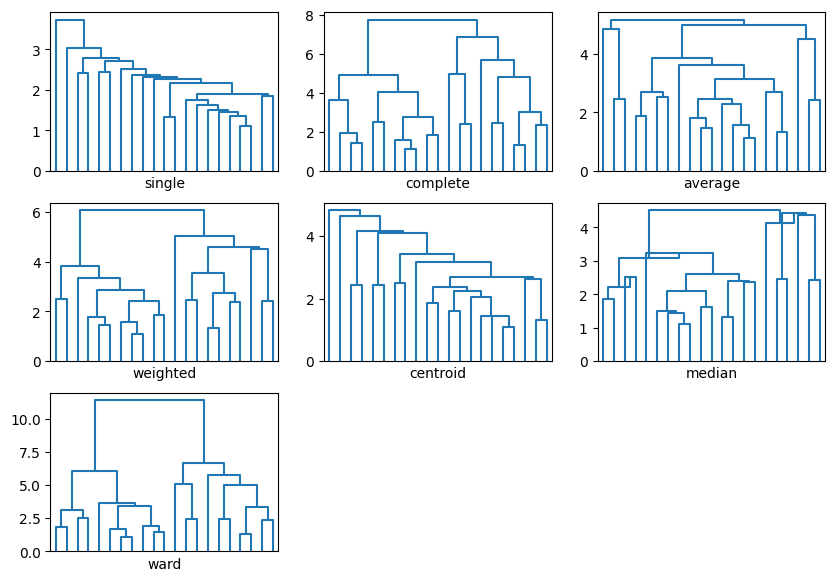

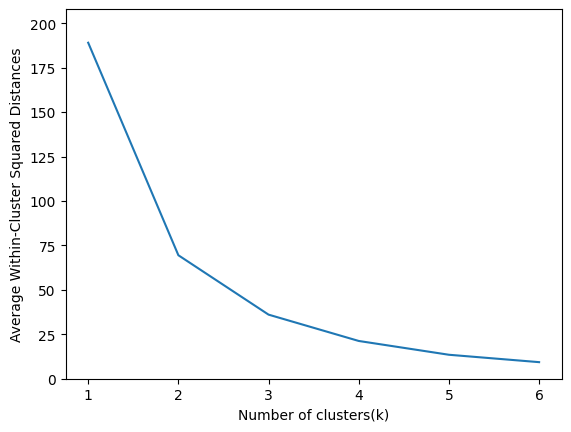

In [23]:
# k-means clustering
inertia = []
for n_clusters in range(1, 7):
    kmeans = KMeans(n_clusters=n_clusters, random_state=1).fit(pharma_norm)
    inertia.append(kmeans.inertia_ / n_clusters)
inertias = pd.DataFrame({'n_clusters': range(1, 7), 'inertia': inertia})
ax = inertias.plot(x='n_clusters', y='inertia')
plt.xlabel('Number of clusters(k)')
plt.ylabel('Average Within-Cluster Squared Distances')
plt.ylim((0, 1.1 * inertias.inertia.max()))
ax.legend().set_visible(False)
plt.show()

In [ ]:
# Answer:

# Three to four clusters seem to be a good choice.

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=0).fit(pharma_norm)

c:\Users\rcc_0\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4, random_state=0)

In [ ]:
# Two factors can help us decide how many clusters to form:

# 1. The purpose of the inquiry. How many clusters are we going to want to deal with?

# In this case, to understand the structure of the industry in financial terms we might use basic domain knowledge to consider that size and financial 
# performance are fundamental dimensions into which our various metrics fall. To make sense of our analysis, we will need at least two clusters, but 
# more than 3 or 4 will probably defeat the purpose of clustering, which is to simplify matters (at least for the purposes of initial analysis).

# 2. How do the clusters look when trying 2, 3, 4, 5 clusters? Are they nicely separated? Do they have enough members to be useful? Do they look like
# natural clusters (as opposed to arbitrary decisions about cluster membership)?

# Normalizing the data is important to ensure that the "distance measured" accords equal weight to each variable. Without normalization, the variable
# with the largest scale will dominate the measure. 

# Trying both k-means and hierarchical clustering, k-means of 3 and 4, and hierarchical clustering with Wards method give useful results. We will focus 
# mainly on Wards clustering with k=4, but similar analysis could be made for the other choices.

In [ ]:
# 15.2.b Interpret the clusters with respect to the categorical variables used in forming the clusters.

In [26]:
centroids = {}
for key, item in pharma_data.groupby(memb):
    centroids['Cluster {}'.format(key)] = item.mean()

pd.DataFrame(centroids).round(2)

,Cluster 1,Cluster 2,Cluster 3,Cluster 4
Market_Cap,157.02,62.88,26.91,8.82
Beta,0.48,0.41,0.64,0.62
PE_Ratio,22.22,20.23,55.63,19.61
ROE,44.42,30.71,10.10,16.96
ROA,17.70,13.39,4.20,6.24
Asset_Turnover,0.95,0.71,0.70,0.54
Leverage,0.22,0.39,0.32,1.11
Rev_Growth,18.53,5.38,7.00,21.14
Net_Profit_Margin,19.58,20.51,5.13,13.19


In [ ]:
# Answer:

# Cluster 1 companies are big (market cap), fast growing, profitable, and not leveraged.
# Cluster 2 companies are of moderate size (market cap), slow growing, profitable, and not leveraged.
# Cluster 3 companies are small (market cap), slow growing, of low profitability, and not leveraged.
# Cluster 4 companies are small (market cap), fast growing, profitable, and highly leveraged.

In [ ]:
# 15.2.c Is there a pattern in the clusters with respect to the numerical variables (10-12)? (those not used in forming the clusters).

In [27]:
pd.DataFrame(pd.Series(item.Median_Recommendation.value_counts(), name=f'Cluster {key}') 
             for key, item in pharma_df.groupby(memb))

Median_Recommendation,Hold,Moderate Buy,Moderate Sell,Strong Buy
Cluster 1,2.0,2.0,NaN,NaN
Cluster 2,4.0,1.0,2.0,NaN
Cluster 3,2.0,1.0,NaN,NaN
Cluster 4,1.0,3.0,2.0,1.0


In [ ]:
# Answer for variable 10, Median_Recommendation.

# With respect to buy/hold recommendations, clusters 2 and 4 are the interesting ones, characterized by mixed recommendations for each.  
# Cluster 4 has recommendations ranging from "moderate sell" to "strong buy".

In [28]:
pd.DataFrame(pd.Series(item.Location.value_counts(), name=f'Cluster {key}') 
             for key, item in pharma_df.groupby(memb))

Location,US,UK,SWITZERLAND,CANADA,GERMANY,FRANCE,IRELAND
Cluster 1,3.0,1.0,NaN,NaN,NaN,NaN,NaN
Cluster 2,5.0,1.0,1.0,NaN,NaN,NaN,NaN
Cluster 3,1.0,NaN,NaN,1.0,1.0,NaN,NaN
Cluster 4,4.0,1.0,NaN,NaN,NaN,1.0,1.0


In [ ]:
# Answer for variable 11, Location.

# With respect to country, the US has a significant presence in three of four clusters, with cluster 2 having 5 US firms. Other countries 
# are represented to a much smaller degree in the clusters.

In [29]:
pd.DataFrame(pd.Series(item.Exchange.value_counts(), name=f'Cluster {key}') 
             for key, item in pharma_df.groupby(memb))

Exchange,NYSE,NASDAQ,AMEX
Cluster 1,4.0,NaN,NaN
Cluster 2,7.0,NaN,NaN
Cluster 3,3.0,NaN,NaN
Cluster 4,5.0,1.0,1.0


In [ ]:
# Answer for variable 12, Exchange.

# With respect to exchange, there are only two non-NYSE firms in the data set, and they are in cluster 4, one of the "small firms" cluster. 
# This is consistent with the nature of the AMEX and NASDAQ, which typically host smaller firms than the NYSE.

In [ ]:
# 15.2.d Provide an appropriate name for each cluster using any or all of the variables in the dataset.

# Answer:

# Cluster 1: Large Cap-Fast Growth-High Profit
# Cluster 2: Mid Cap-Slow Growth-High Profit
# Cluster 3: Small Cap-Slow Growth-Low Profit
# Cluster 4: Samll Cap-Fast Growth-Moderate Profit